## 1. Operations

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchquantum.plugin.cuquantum import *
from torchquantum.operator.standard_gates import *

In [2]:
import torchquantum as tq
import torchquantum.functional as tqf
q_dev = tq.QuantumDevice(n_wires=1)
q_dev.reset_states(bsz=1)
print(f"all zero state: {q_dev}")
tqf.h(q_dev, wires=0)
print(f"after h gate: {q_dev}")

tqf.rx(q_dev, wires=0, params=[0.3])

print(f"after rx gate: {q_dev}")

all zero state:  class: QuantumDevice 
 device name: default 
 number of qubits: 1 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[1.+0.j, 0.+0.j]], dtype=complex64)
after h gate:  class: QuantumDevice 
 device name: default 
 number of qubits: 1 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[0.70710677+0.j, 0.70710677+0.j]], dtype=complex64)
after rx gate:  class: QuantumDevice 
 device name: default 
 number of qubits: 1 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[0.6991667-0.10566872j, 0.6991667-0.10566872j]], dtype=complex64)


In [3]:
# Method 1: Using cuquantum ParameterizedQuantumCircuit
n_wires = 1

# Create a parameterized quantum circuit with cuquantum backend
circuit = ParameterizedQuantumCircuit(n_wires=n_wires, n_input_params=0)


# Add gates to the circuit
circuit.append_gate(Hadamard, wires=0)
circuit.append_gate(RX, wires=0, fixed_params=[0.3])

backend = CuTensorNetworkBackend(TNConfig(num_hyper_samples=1))
sampling = QuantumSampling(circuit, backend, 100)
print(sampling())

[{'0': np.int64(54), '1': np.int64(46)}]


Traditional TorchQuantum sampling:


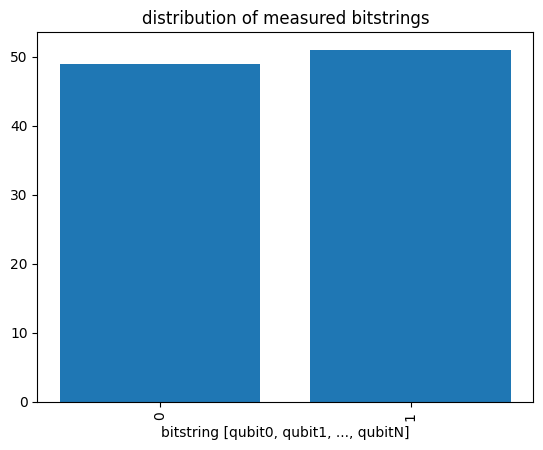

Traditional result: [OrderedDict([('0', 49), ('1', 51)])]


In [4]:
# For comparison: Traditional TorchQuantum sampling approach
print("Traditional TorchQuantum sampling:")
q_dev_compare = tq.QuantumDevice(n_wires=1)
q_dev_compare.reset_states(bsz=1)

# Apply the same gates
tqf.h(q_dev_compare, wires=0)
tqf.rx(q_dev_compare, wires=0, params=[0.3])

# Sample using TorchQuantum's measure function
traditional_samples = tq.measure(q_dev_compare, n_shots=100, draw_id=0)
print(f"Traditional result: {traditional_samples}")

# The results should be statistically similar (both are sampling from the same quantum state)

In [5]:
# Gradient-based optimization with cuQuantum
print("=== Gradient-Based Optimization with cuQuantum ===")

# Reset and create a new circuit for optimization
n_wires = 8
circuit_opt = ParameterizedQuantumCircuit(n_wires=n_wires, n_input_params=0, n_trainable_params=16)
for layer in range(4):
    for wire in range(n_wires):
        circuit_opt.append_gate(Hadamard, wires=wire)
    for wire in range(n_wires-1):
        circuit_opt.append_gate(CNOT, wires=[wire, wire+1])
    for wire in range(n_wires):
        circuit_opt.append_gate(RX, wires=wire, trainable_idx=layer + wire)

# Initialize parameter randomly
circuit_opt.set_trainable_params(torch.randn(16))

# Create optimizer - FIX: Wrap trainable_params in a list!
print("Parameters shape:", circuit_opt.trainable_params.shape)
print("Parameters type:", type(circuit_opt.trainable_params))
optimizer = torch.optim.Adam([circuit_opt.trainable_params], lr=0.01)  # Note the []

# Target: maximize amplitude of specific state
target_bitstring = "00000000"  # All zeros state for 8 qubits
backend_opt = CuTensorNetworkBackend(TNConfig(num_hyper_samples=1))
amplitude_module_opt = QuantumAmplitude(circuit_opt, backend_opt, [target_bitstring])

print(f"Starting optimization to reach |{target_bitstring}⟩ state...")
print("Initial parameters (first few):", circuit_opt.trainable_params[:5].detach().numpy())

# Optimization loop
for step in range(50):
    optimizer.zero_grad()
    
    # Compute amplitude and loss
    amplitude = amplitude_module_opt()
    loss = 1 - amplitude.abs()  # Minimize this to maximize amplitude
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if step % 5 == 0:
        print(f"Step {step:2d}: amplitude={amplitude.abs().item():.6f}, loss={loss.item():.6f}")
        print(f"         gradients norm: {circuit_opt.trainable_params.grad.norm().item():.6f}")

print(f"\nFinal amplitude for |{target_bitstring}⟩: {amplitude.abs().item():.6f}")


=== Gradient-Based Optimization with cuQuantum ===
Parameters shape: torch.Size([16])
Parameters type: <class 'torch.nn.parameter.Parameter'>
Starting optimization to reach |00000000⟩ state...
Initial parameters (first few): [-1.1306666  -0.09106943 -0.9094527   2.2768314   0.99367696]
Step  0: amplitude=0.086376, loss=0.913624
         gradients norm: 0.214764


/home/zkysfls/torchquantum/torchquantum/plugin/cuquantum/cutn/gradient.py:48: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:307.)
  grads[arg_idx][var_idx] = grad_output * (val_plus - val_minus) / delta


Step  5: amplitude=0.105141, loss=0.894859
         gradients norm: 0.217477
Step 10: amplitude=0.127305, loss=0.872695
         gradients norm: 0.238538
Step 10: amplitude=0.127305, loss=0.872695
         gradients norm: 0.238538
Step 15: amplitude=0.152420, loss=0.847580
         gradients norm: 0.259759
Step 15: amplitude=0.152420, loss=0.847580
         gradients norm: 0.259759
Step 20: amplitude=0.180303, loss=0.819697
         gradients norm: 0.278466
Step 20: amplitude=0.180303, loss=0.819697
         gradients norm: 0.278466
Step 25: amplitude=0.210954, loss=0.789046
         gradients norm: 0.295565
Step 25: amplitude=0.210954, loss=0.789046
         gradients norm: 0.295565
Step 30: amplitude=0.244110, loss=0.755890
         gradients norm: 0.307360
Step 30: amplitude=0.244110, loss=0.755890
         gradients norm: 0.307360
Step 35: amplitude=0.278897, loss=0.721103
         gradients norm: 0.313127
Step 35: amplitude=0.278897, loss=0.721103
         gradients norm: 0.313127

## 2. Model class

In [6]:
class QModel(tq.QuantumModule):
    def __init__(self):
        super().__init__()
        self.n_wires = 2
        self.u3_0 = tq.U3(has_params=True, trainable=True)
        self.u3_1 = tq.U3(has_params=True, trainable=True)
        self.cu3_0 = tq.CU3(has_params=True, trainable=True)
        self.cu3_1 = tq.CU3(has_params=True, trainable=True)
        self.u3_2 = tq.U3(has_params=True, trainable=True)
        self.u3_3 = tq.U3(has_params=True, trainable=True)
        #self.random_layer = tq.RandomLayer(n_ops=10,
        #                                   wires=list(range(self.n_wires)))

    def forward(self, q_device: tq.QuantumDevice):
        self.u3_0(q_device, wires=0)
        self.u3_1(q_device, wires=1)
        self.cu3_0(q_device, wires=[0, 1])
        self.u3_2(q_device, wires=0)
        self.u3_3(q_device, wires=1)
        self.cu3_1(q_device, wires=[1, 0])
        #self.random_layer(q_device)


q_dev = tq.QuantumDevice(n_wires=2)
q_dev.reset_states(bsz=3)
print(q_dev)

model = QModel()
model(q_dev)
print(q_dev)

 class: QuantumDevice 
 device name: default 
 number of qubits: 2 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]], dtype=complex64)
 class: QuantumDevice 
 device name: default 
 number of qubits: 2 
 batch size: 1 
 current computing device: cpu 
 recording op history: False 
 current states: array([[ 0.75102925+0.0200534j , -0.11806175-0.33148786j,
         0.3145066 +0.4528266j ,  0.02394111-0.08479779j],
       [ 0.75102925+0.0200534j , -0.11806175-0.33148786j,
         0.3145066 +0.4528266j ,  0.02394111-0.08479779j],
       [ 0.75102925+0.0200534j , -0.11806175-0.33148786j,
         0.3145066 +0.4528266j ,  0.02394111-0.08479779j]],
      dtype=complex64)


In [7]:


# Corrected cuQuantum version that matches the TorchQuantum structure
class QModelCuQuantumCorrected(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.n_wires = 2
        
        # Create circuit with same structure as TorchQuantum version
        # 6 gates × 3 params each = 18 total parameters
        self.circuit = ParameterizedQuantumCircuit(
            n_wires=self.n_wires, 
            n_input_params=0, 
            n_trainable_params=18
        )
        
        # Initialize parameters (make them trainable for optimization)
        initial_params = torch.randn(18, requires_grad=True)
        self.circuit.set_trainable_params(initial_params)
        
        # Add gates in the same order as TorchQuantum version
        self.circuit.append_gate(U3, wires=0, trainable_idx=[0, 1, 2])      # u3_0
        self.circuit.append_gate(U3, wires=1, trainable_idx=[3, 4, 5])      # u3_1  
        self.circuit.append_gate(CU3, wires=[0, 1], trainable_idx=[6, 7, 8])  # cu3_0
        self.circuit.append_gate(U3, wires=0, trainable_idx=[9, 10, 11])    # u3_2
        self.circuit.append_gate(U3, wires=1, trainable_idx=[12, 13, 14])   # u3_3
        self.circuit.append_gate(CU3, wires=[1, 0], trainable_idx=[15, 16, 17])  # cu3_1 
        

        
        # Create backend and expectation measurement  
        backend = CuTensorNetworkBackend(TNConfig(num_hyper_samples=1))
        self.energy = QuantumExpectation(self.circuit, backend, [{"IZ": 1.0}])  # Note: dict format

    def forward(self):
        output = self.energy()
        return output


# Test the corrected version
print("\nTesting corrected cuQuantum implementation:")
model_corrected = QModelCuQuantumCorrected()
result = model_corrected()
print(f"Expectation value: {result.item():.6f}")
print(f"Parameters shape: {model_corrected.circuit.trainable_params.shape}")



Testing corrected cuQuantum implementation:
Expectation value: 0.882402
Parameters shape: torch.Size([18])


In [8]:
def optimize(model, n_steps=100, lr=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    print(f"The initial parameters are:\n{next(model.parameters()).data.tolist()}")
    print("")
    for step in range(n_steps):
        optimizer.zero_grad()
        loss = model()
        start_time = torch.cuda.Event(enable_timing=True)
        end_time = torch.cuda.Event(enable_timing=True)

        start_time.record()
        loss.backward()
        end_time.record()

        torch.cuda.synchronize()
        elapsed_time = start_time.elapsed_time(end_time)
        print(f"Backward pass took {elapsed_time:.2f} ms")

        optimizer.step()

        print(f"Step: {step}, Cost Objective: {loss.item()}")

    print("")
    print(f"The optimal parameters are:\n{next(model.parameters()).data.tolist()}")
    print("")

model_corrected = QModelCuQuantumCorrected()
optimize(model_corrected, n_steps=10, lr=0.01)
result = model_corrected()
print(f"Expectation value: {result.item():.6f}")


The initial parameters are:
[0.7232231497764587, -0.8105312585830688, -0.29326990246772766, 0.14994484186172485, -0.5617180466651917, 0.22708554565906525, -0.31306278705596924, 0.6680203676223755, -0.44283345341682434, 0.39733049273490906, -1.415021538734436, -0.4423304796218872, -0.7390486001968384, 1.4334053993225098, -0.9185096025466919, 0.02780008688569069, -1.6929177045822144, 2.3480868339538574]

Backward pass took 56.73 ms
Step: 0, Cost Objective: 0.7153363227844238
Backward pass took 58.19 ms
Step: 1, Cost Objective: 0.7043275237083435
Backward pass took 50.80 ms
Step: 2, Cost Objective: 0.6928059458732605
Backward pass took 50.38 ms
Step: 3, Cost Objective: 0.6807578206062317
Backward pass took 42.66 ms
Step: 4, Cost Objective: 0.6681620478630066
Backward pass took 43.81 ms
Step: 5, Cost Objective: 0.6550008654594421
Backward pass took 41.17 ms
Step: 6, Cost Objective: 0.641255795955658
Backward pass took 29.15 ms
Step: 7, Cost Objective: 0.6269086003303528
Backward pass took 

# 3. VQE

In [9]:
import torchquantum as tq
import torch
import torch.nn.functional as F
from torchquantum.util.vqe_utils import parse_hamiltonian_file
from torchquantum.dataset import VQE
import random
import numpy as np
import argparse
import torch.optim as optim

from torch.optim.lr_scheduler import CosineAnnealingLR, ConstantLR


In [10]:
class QVQEModel(tq.QuantumModule):
    def __init__(self, arch, hamil_info):
        super().__init__()
        self.arch = arch
        self.hamil_info = hamil_info
        self.n_wires = hamil_info['n_wires']
        self.n_blocks = arch['n_blocks']
        self.u3_layers = tq.QuantumModuleList()
        self.cu3_layers = tq.QuantumModuleList()
        for _ in range(self.n_blocks):
            self.u3_layers.append(tq.Op1QAllLayer(op=tq.U3,
                                                  n_wires=self.n_wires,
                                                  has_params=True,
                                                  trainable=True,
                                                  ))
            self.cu3_layers.append(tq.Op2QAllLayer(op=tq.CU3,
                                                   n_wires=self.n_wires,
                                                   has_params=True,
                                                   trainable=True,
                                                   circular=True
                                                   ))
        self.measure = tq.MeasureMultipleTimes(
            obs_list=hamil_info['hamil_list'])

    def forward(self, q_device):
        q_device.reset_states(bsz=1)
        for k in range(self.n_blocks):
            self.u3_layers[k](q_device)
            self.cu3_layers[k](q_device)
        x = self.measure(q_device)

        hamil_coefficients = torch.tensor([hamil['coefficient'] for hamil in
                                           self.hamil_info['hamil_list']],
                                          device=x.device).double()

        for k, hamil in enumerate(self.hamil_info['hamil_list']):
            for wire, observable in zip(hamil['wires'], hamil['observables']):
                if observable == 'i':
                    x[k][wire] = 1
            for wire in range(q_device.n_wires):
                if wire not in hamil['wires']:
                    x[k][wire] = 1

        x = torch.cumprod(x, dim=-1)[:, -1].double()
        x = torch.dot(x, hamil_coefficients)

        if x.dim() == 0:
            x = x.unsqueeze(0)

        return x


def train(dataflow, q_device, model, device, optimizer):
    for _ in dataflow['train']:
        outputs = model(q_device)
        loss = outputs.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Expectation of energy: {loss.item()}")


def valid_test(dataflow, q_device, split, model, device):
    with torch.no_grad():
        for _ in dataflow[split]:
            outputs = model(q_device)
    loss = outputs.mean()

    print(f"Expectation of energy: {loss}")

In [11]:
class Args(object):
  def __init__(self):
    pass

def main():
    # parser = argparse.ArgumentParser()
    # parser.add_argument('--pdb', action='store_true', help='debug with pdb')
    # parser.add_argument('--n_blocks', type=int, default=2,
    #                     help='number of blocks, each contain one layer of '
    #                          'U3 gates and one layer of CU3 with '
    #                          'ring connections')
    # parser.add_argument('--steps_per_epoch', type=int, default=10,
    #                     help='number of training epochs')
    # parser.add_argument('--epochs', type=int, default=100,
    #                     help='number of training epochs')
    # parser.add_argument('--hamil_filename', type=str, default='./h2_new.txt',
    #                     help='number of training epochs')

    args = Args()
    args.n_blocks = 2
    args.steps_per_epoch=100
    args.epochs=100
    args.hamil_filename = 'h2_new.txt'

    # if args.pdb:
    #     import pdb
    #     pdb.set_trace()

    seed = 0
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    dataset = VQE(steps_per_epoch=args.steps_per_epoch)

    dataflow = dict()

    for split in dataset:
        if split == 'train':
            sampler = torch.utils.data.RandomSampler(dataset[split])
        else:
            sampler = torch.utils.data.SequentialSampler(dataset[split])
        dataflow[split] = torch.utils.data.DataLoader(
            dataset[split],
            batch_size=1,
            sampler=sampler,
            num_workers=1,
            pin_memory=True)

    hamil_info = parse_hamiltonian_file(args.hamil_filename)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")
    model = QVQEModel(arch={"n_blocks": args.n_blocks},
                       hamil_info=hamil_info)

    model.to(device)

    n_epochs = args.epochs
    optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

    q_device = tq.QuantumDevice(n_wires=hamil_info['n_wires'])
    q_device.reset_states(bsz=1)

    for epoch in range(1, n_epochs + 1):
        # train
        print(f"Epoch {epoch}, LR: {optimizer.param_groups[0]['lr']}")
        train(dataflow, q_device, model, device, optimizer)

        # valid
        valid_test(dataflow, q_device, 'valid', model, device)
        scheduler.step()

    # final valid
    valid_test(dataflow, q_device, 'valid', model, device)

In [12]:
main()

Epoch 1, LR: 0.005
Expectation of energy: -0.3082973230728011
Expectation of energy: -0.3150707638089269
Expectation of energy: -0.32225806677983054
Expectation of energy: -0.32985389654800246
Expectation of energy: -0.3378548957310795
Expectation of energy: -0.3462579786169898
Expectation of energy: -0.3550608077597749
Expectation of energy: -0.3642612311998784
Expectation of energy: -0.37385944329722354
Expectation of energy: -0.3838581392187024
Expectation of energy: -0.3942625904653395
Expectation of energy: -0.4050825282943114
Expectation of energy: -0.3082973230728011
Expectation of energy: -0.3150707638089269
Expectation of energy: -0.32225806677983054
Expectation of energy: -0.32985389654800246
Expectation of energy: -0.3378548957310795
Expectation of energy: -0.3462579786169898
Expectation of energy: -0.3550608077597749
Expectation of energy: -0.3642612311998784
Expectation of energy: -0.37385944329722354
Expectation of energy: -0.3838581392187024
Expectation of energy: -0.394

KeyboardInterrupt: 

## 4. QNN circuit

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchquantum.plugin.cuquantum import *
from torchquantum.operator.standard_gates import *
import torchquantum as tq
import torchquantum.functional as tqf
import math, random
import torch
from torchquantum.plugin.cuquantum import ParameterizedQuantumCircuit, CuTensorNetworkBackend, TNConfig, QuantumSampling
from torchquantum.operator.standard_gates import RX, RY, RZ, Hadamard, CNOT

In [2]:
class QFCModel(tq.QuantumModule):
    class QLayer(tq.QuantumModule):
        def __init__(self):
            super().__init__()
            self.n_wires = 4

            # Define circuit and trainable params
            self.circuit = ParameterizedQuantumCircuit(
                n_wires=self.n_wires,
                n_input_params=0,
                n_trainable_params=18,
            )
            initial_params = torch.randn(18, requires_grad=True)
            self.circuit.set_trainable_params(initial_params)

            # Circuit structure (example)
            self.circuit.append_gate(U3, wires=0, trainable_idx=[0, 1, 2])      # u3_0
            self.circuit.append_gate(U3, wires=1, trainable_idx=[3, 4, 5])      # u3_1
            self.circuit.append_gate(CU3, wires=[1, 2], trainable_idx=[6, 7, 8])  # cu3_0
            self.circuit.append_gate(U3, wires=1, trainable_idx=[9, 10, 11])    # u3_2
            self.circuit.append_gate(U3, wires=2, trainable_idx=[12, 13, 14])   # u3_3
            self.circuit.append_gate(CU3, wires=[2, 3], trainable_idx=[15, 16, 17])  # cu3_1

            # Backend + expectation: measure Z on last qubit (wire 3) => 'IIIZ' (string length = n_wires)
            self.backend = CuTensorNetworkBackend(TNConfig(num_hyper_samples=1))
            # Observable dictionary: each term is a dict mapping Pauli string to coefficient
            self.expect = QuantumExpectation(self.circuit, self.backend, [{"IIIZ": 1.0}])

        def forward(self, x=None):
            """Forward pass.
            x (optional): ignored for now; placeholder for future data encoding.
            Returns a scalar expectation value tensor (shape [1]).
            """
            out = self.expect()  # tensor of shape [1]
            return out

    def __init__(self):
        super().__init__()
        self.layer = self.QLayer()

    def forward(self, x=None):
        return self.layer(x)


def train(dataflow, model, device, optimizer, steps=100, log_every=10):
    """Minimal training loop.
    If dataflow is None, uses dummy iterations optimizing expectation -> 0.
    Loss: mean(out^2) so we try to drive expectation toward 0.
    """
    model.train()
    it = 0
    if dataflow is None:
        while it < steps:
            optimizer.zero_grad()
            out = model()  # shape [1]
            loss = (out ** 2).mean()
            loss.backward()
            optimizer.step()
            if it % log_every == 0:
                print(f"Step {it:03d}  Expect={out.item():+.6f}  Loss={loss.item():.6f}")
            it += 1
    else:
        for batch in dataflow:
            if it >= steps:
                break
            optimizer.zero_grad()
            # Expect batch can be (x,y) or just x; handle flexibly
            if isinstance(batch, (list, tuple)) and len(batch) > 1:
                x, y = batch[0], batch[1]
                out = model(x.to(device))
                # If y is scalar/1-dim target: MSE; otherwise reduce
                y = y.to(device).view_as(out)
                loss = ((out - y) ** 2).mean()
            else:
                x = batch[0] if isinstance(batch, (list, tuple)) else batch
                out = model(x.to(device) if torch.is_tensor(x) else None)
                loss = (out ** 2).mean()
            loss.backward()
            optimizer.step()
            if it % log_every == 0:
                print(f"Step {it:03d}  Expect={out.item():+.6f}  Loss={loss.item():.6f}")
            it += 1
    return model


def valid_test(dataflow, model, device):
    model.eval()
    losses = []
    with torch.no_grad():
        if dataflow is None:
            out = model()
            loss = (out ** 2).mean()
            losses.append(loss.item())
        else:
            for batch in dataflow:
                if isinstance(batch, (list, tuple)) and len(batch) > 1:
                    x, y = batch[0], batch[1]
                    out = model(x.to(device))
                    y = y.to(device).view_as(out)
                    loss = ((out - y) ** 2).mean()
                else:
                    x = batch[0] if isinstance(batch, (list, tuple)) else batch
                    out = model(x.to(device) if torch.is_tensor(x) else None)
                    loss = (out ** 2).mean()
                losses.append(loss.item())
    avg = sum(losses) / max(1, len(losses))
    print(f"Validation average loss: {avg:.6f}")
    return avg

# --- Quick demo (dummy training) ---
model = QFCModel()
optimizer = torch.optim.Adam([model.layer.circuit.trainable_params], lr=0.02)
train(None, model, device=torch.device('cpu'), optimizer=optimizer, steps=30, log_every=5)
valid_test(None, model, device=torch.device('cpu'))

Step 000  Expect=+0.719480  Loss=0.517651
Step 005  Expect=+0.639888  Loss=0.409456
Step 010  Expect=+0.549973  Loss=0.302470
Step 015  Expect=+0.450998  Loss=0.203400
Step 010  Expect=+0.549973  Loss=0.302470
Step 015  Expect=+0.450998  Loss=0.203400
Step 020  Expect=+0.346365  Loss=0.119968
Step 025  Expect=+0.241620  Loss=0.058380
Validation average loss: 0.020756
Step 020  Expect=+0.346365  Loss=0.119968
Step 025  Expect=+0.241620  Loss=0.058380
Validation average loss: 0.020756


0.02075638808310032